In [1]:
import numpy as np
import torch
from torch.autograd import grad
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim.lr_scheduler import ExponentialLR

import seaborn as sns
from scipy.io import savemat, loadmat
from torch.optim.lr_scheduler import ExponentialLR, MultiStepLR

import torch.nn as nn
import torch.nn.functional as F
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from scipy.linalg import sqrtm
from chebyshev_utils import *
from GEOMLOSS import samples_loss

import matplotlib as mpl
import matplotlib.font_manager
fpaths = matplotlib.font_manager.findSystemFonts()
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })
matplotlib.rcParams.update({'font.size': 16})


2026-01-18 14:00:41.960037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768762841.978874   97510 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768762841.994032   97510 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Simulate toggle-switch and generate data with drift and growth dynamics of the form
### $f_1(x_1, x_2) = a_1 \frac{x_1^n}{k_1^n + x_1^n} + b_1 \frac{k_1^n}{k_1^n + x_2^n}, \quad f_2(x_1, x_2) = a_2 \frac{x_2^n}{k_2^n + x_2^n} + b_2 \frac{k_2^n}{k_2^n + x_1^n}$

### $g(x_1, x_2) = g_r \frac{x_2^2}{1+x_2^2}$


In [3]:
from tqdm import tqdm
def toggle_switch(x,model_params_):
    a1, a2, b1, b2, K1, K2, n = model_params_

    x_ = np.zeros_like(x)
    f = np.zeros_like(x);
    xn = x**n + 0;
    f[:,0] = (a1*(xn[:,0])/(K1**n + xn[:,0])) + b1*(K1**n)/(K1**n + xn[:,1]) # degration is always set to one
    f[:,1] = (a2*(xn[:,1])/(K2**n + xn[:,1])) + b2*(K2**n)/(K2**n + xn[:,0]) # degration is always set to one

    return f

def g_rate(x1,x2,gr):
    """Growth propensity based on gene2 expression."""
    return  gr*( 1.0*(x2**2)/(1+x2**2)  + 0.0*(x1**2)/(1+x1**2) )

def simulate_toggle_with_growth(nsamples, init, Nsnaps, Ndim, seed_, maxiter, model_params, vol, gr, growth_flag=False, reaction_flag=False):
    dt = 0.01; lx = 1
    np.random.seed(seed_)

    xold = init + 0.1*np.random.normal(0,1, (Ndim, nsamples)) #0*np.zeros((Ndim, nsamples))  # shape (Ndim, nsamples)
    tt = np.zeros(Nsnaps)
    samples_fullx = []  # will store a list of arrays with shape (n(t), Ndim)

    steps = int(maxiter / Nsnaps)

    #for snap in range(Nsnaps):
    for snap in tqdm(range(Nsnaps), desc="Snapshots"):
        
        t_snap = snap * steps * dt
        tt[snap] = t_snap

        for _ in range(steps):
        #for _ in tqdm(range(steps), leave=False, desc="Time steps"):
            if(reaction_flag):
                fval = toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;
            else:
                fval = 0.01*toggle_switch(xold.T, model_params).T  # (Ndim, nsamples)
                noise = np.sqrt(fval + 0.1*lx * xold) * np.sqrt(dt) * np.random.normal(0, 1, xold.shape)
                xnew = xold + dt * (fval - 0.1*lx * xold) + (1 / np.sqrt(vol)) * noise

            # Reflect negatives
                xnew = np.where(xnew < 0, xold, xnew)
                xold = xnew + 0;

            if(growth_flag):
                x1 = xold[0]; x2 = xold[1];
                growth_probs = g_rate(x1, x2, gr) * dt
                divide_flags = np.random.rand(x2.shape[0]) < growth_probs
                new_cells = xold[:, divide_flags]  # shape: (Ndim, #dividing cells)

                if new_cells.shape[1] > 0:
                    xold = np.concatenate([xold, new_cells], axis=1)

        samples_fullx.append(xold.T.copy())

    return samples_fullx, tt

#### model_params = [a1, a2, b1, b2, K1, K2, n]
model_params = np.array([2., 2., 1.0, 1.0, 1.0, 1.0, 4.0])

### hyper-parameters of the simulation
Ndim = 2; vol = 4.0; nsamples = 2001; Nsnaps = 10; seed = 0; maxiter = 200; 

gr = 2.0; #growth-rate
growth_flag_ = True; # Set True if growth is modeled
reaction_flag_ = True; # Set True if the reaction is modeled 
init = np.random.uniform(0.25,0.75,(Ndim,nsamples)) + 0;
# init[0,:] = init[0,:] ;
samples_full, tt = simulate_toggle_with_growth(nsamples,init,Nsnaps,Ndim,seed,maxiter,model_params,vol,gr,\
                                               growth_flag=growth_flag_,reaction_flag=reaction_flag_);
samples_full = samples_full[:] 
nsnaps = len(samples_full); 
dt = tt[1] - tt[0];
print(" physical-times of measurement ", tt, " dt ", dt, " nsnaps ", nsnaps)

Snapshots: 100%|██████████| 10/10 [00:00<00:00, 77.03it/s]

 physical-times of measurement  [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]  dt  0.2  nsnaps  10


### Population-growth

In [4]:
mass_vec = np.ones((nsnaps,))
for k in range(1,nsnaps):
    mass_vec[k] = len(samples_full[k])/len(samples_full[0])
    print(" # samples at time ", np.round(tt[k],3), ":", len(samples_full[k]))
mass_vec = torch.tensor(mass_vec,dtype=torch.float32,device=device)
print(" ground-truth mass ratio over time ", mass_vec)

 # samples at time  0.2 : 2521
 # samples at time  0.4 : 2931
 # samples at time  0.6 : 3424
 # samples at time  0.8 : 4145
 # samples at time  1.0 : 5177
 # samples at time  1.2 : 6515
 # samples at time  1.4 : 8449
 # samples at time  1.6 : 11102
 # samples at time  1.8 : 14656
 ground-truth mass ratio over time  tensor([1.0000, 1.1475, 1.3341, 1.5585, 1.8867, 2.3564, 2.9654, 3.8457, 5.0533,
        6.6709], device='cuda:0')


### Time-resolved Snapshots

(2197, 2)
(2521, 2)
(2931, 2)
(3424, 2)
(4145, 2)
(5177, 2)
(6515, 2)
(8449, 2)
(11102, 2)
(14656, 2)


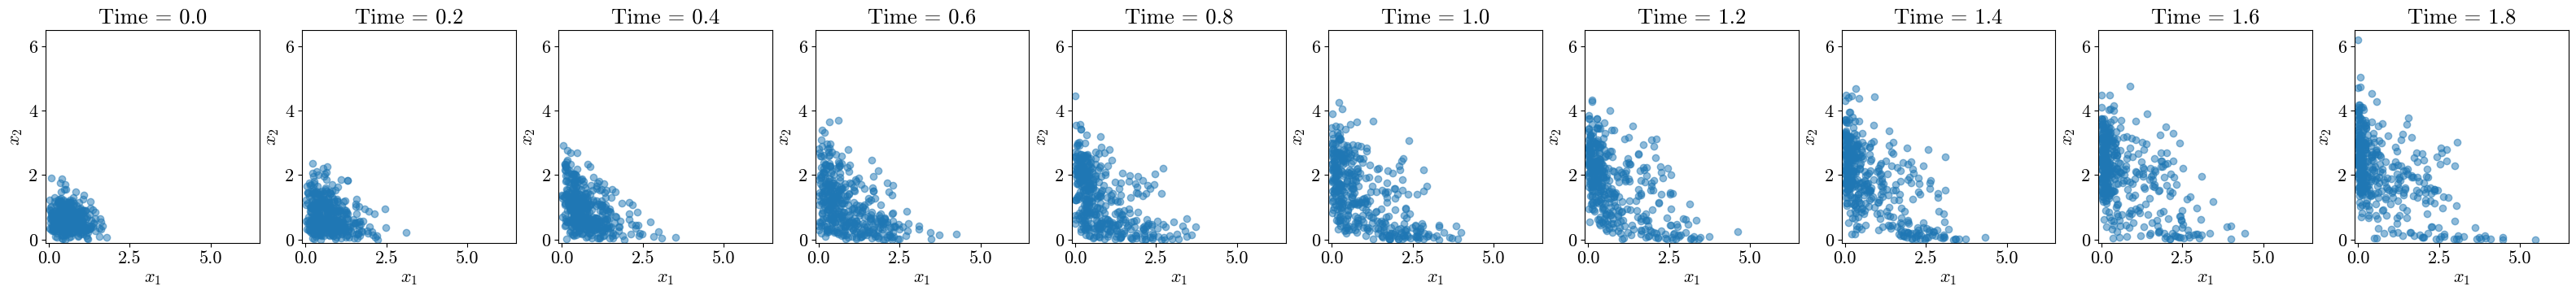

In [5]:
for k in range(0, len(samples_full)):
    plt.subplot(1,len(samples_full),k+1)
    print(samples_full[k].shape)
    ind_s = np.arange(0,samples_full[k].shape[0])
    np.random.shuffle(ind_s)
    plt.scatter(samples_full[k][ind_s[0:400],0],samples_full[k][ind_s[0:400],1],alpha=0.5)
    
    plt.xlim(-0.1,6.5); plt.ylim(-0.1,6.5);
    plt.title(r'Time = '+ str(np.round(tt[k],3)))
    plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.gcf().set_size_inches(40,3.4)

### Multi-Marginal Optimal Transport

In [6]:
def MMOT_trajectories(samples_):
    nrep = 1;
    print(" # of repetitions ", nrep)

    min_index = np.argmin([arr.shape[0] for arr in samples_])
    nsamples_ = samples_[min_index].shape[0]

    print("Index with fewest samples:", min_index)
    print("Smallest N:", nsamples_)
    
    ### shuffle data to de-correlate the data in time
    Dist_ = np.zeros((len(samples_),nrep,nsamples_,Ndim))   
    for k in range(0, len(samples_)):
        ind_s = np.arange(0,samples_[k].shape[0])
        for j in range(0, nrep):
            np.random.shuffle(ind_s)
            Dist_[k,j,:,:] = samples_[k][ind_s[0:nsamples_],0:Ndim]

    ### Trajectory sampling
    Dist = np.zeros((len(samples_),nrep*nsamples_,Ndim))
    batch_ot_samples  =  torch.tensor(np.zeros((len(samples_),nrep*nsamples_,Ndim)),dtype=torch.float32,device=device)
    for j in range(0, nrep):
        before_ot = torch.tensor(Dist_[:,j,:,0:Ndim],dtype=torch.float32)
        Dist[:,j*nsamples_:(j+1)*nsamples_,:] = Dist_[:,j,:,:]
        before_ot = torch.tensor(Dist[:,j*nsamples_:(j+1)*nsamples_,:],dtype=torch.float32)
        batch_ot_samples[:,j*nsamples_:(j+1)*nsamples_,:] = mmot_trajectories(before_ot,nsamples_,device);

    return Dist, batch_ot_samples
        
Dist, batch_ot_samples = MMOT_trajectories(samples_full) #batch_ot_samples
nsamples = Dist.shape[1] + 0;
print(" nsamples ", nsamples, Dist.shape)
tp = tt + 0;

 # of repetitions  1
Index with fewest samples: 0
Smallest N: 2197
 nsamples  2197 (10, 2197, 2)


### Score Training

In [7]:
def setup_model(Ndim, mean, std, Np, seed_, spectral_flag=True):
    """
    Setup the encoder model and optimizer.
    """
    if(spectral_flag):
        print(" Applying Spectral-Norms ")
        encoder = SpectralNormDNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)
    else:
        print(" Vanilla DNN ")
        encoder = DNN(
            sizes=[Ndim + 2, Np, Np, Np, Np, Np, Ndim],
            mean=mean.to(device), std=std.to(device),
            seed=seed_, activation=nn.ELU()
        ).to(device)       
    
    print("#parameters:", sum(p.numel() for p in encoder.parameters() if p.requires_grad))
    return encoder, list(encoder.parameters())

Np = 50; spectral_flag = False; L = 10; n_epochs = 50_01; batch_size_score = nsamples + 0;
X_train, X_data, X_mean, X_std, sigma = generate_noisy_training_data_batch(Dist[:,0:nsamples,:], Ndim, tp, L, nsamples, nsnaps, device);
scoreNet, params = setup_model(Ndim, X_mean, X_std, Np, 0, spectral_flag);
start_time = time.time()
    
scoreNet = DSM_training_batched(Ndim, scoreNet, X_train, X_data, sigma, nsnaps, nsamples, L, adp_flag=1, n_epochs=n_epochs, bs=batch_size_score, device=device);

Snapshots:  10%|█         | 1/10 [00:01<00:09,  1.09s/it]

 Done additing noise to Snapshot at time  0.0


Snapshots:  20%|██        | 2/10 [00:02<00:08,  1.09s/it]

 Done additing noise to Snapshot at time  0.2


Snapshots:  30%|███       | 3/10 [00:03<00:07,  1.09s/it]

...

epoch: 4000 c_: [0.04406762 0.25219983 0.04024962 0.11367639 0.07769893 0.08200848
 0.1176937  0.10161754 0.11676962 0.05401829]


Score Training:  90%|█████████ | 4511/5001 [01:19<00:08, 57.18it/s, loss=3.943e+00, lr=1.00e-05]

epoch: 4500 c_: [0.04408464 0.25528896 0.03821047 0.11826576 0.07920974 0.08209862
 0.113451   0.09290986 0.12125112 0.05522984]


Score Training: 100%|██████████| 5001/5001 [01:27<00:00, 57.08it/s, loss=3.940e+00, lr=1.00e-06]

epoch: 5000 c_: [0.04448663 0.25431746 0.03662593 0.12174641 0.08077099 0.08152272
 0.10948274 0.08552219 0.12848517 0.05703975]


### Score Validation

In [8]:
scoreNet = scoreNet.eval()

def generate_data_DSM(maxiter,infNet,Nsamples,init_,time_,L):
    eps = 1e-4;
    sol = torch.tensor(init_,dtype=torch.float32).to(device)
    sol[:,Ndim+1] = time_
    sigma = geometric_sequence(L);
    for k in range(0,L):
        alpha = eps*((sigma[k]**2)/(sigma[L-1]**2))
        sol[:,Ndim] = sigma[k]
        for t in range(0,500):
            z = torch.normal(0, 1, size=(Nsamples, Ndim)).to(device)
            guru = infNet(sol) 
            sol[:,0:Ndim] = sol[:,0:Ndim] + 0.5*alpha*guru + np.sqrt(alpha)*z
    gen_mean = torch.mean(sol,axis=0)[0:Ndim]      
    sol = sol.cpu().data.numpy().reshape(Nsamples,Ndim+2)
    return sol, gen_mean

def validate_score(scoreNet,Ndim,nsnaps,Dist,L):
    nsamples = Dist.shape[1];
    loss = samples_loss.SamplesLoss("energy")
    maxiter = 100; total_divergence = 0;
    pbar = tqdm(range(int(nsnaps)), desc="Validate", dynamic_ncols=True)
    for tinf in pbar:
        with torch.no_grad():
            infNet = scoreNet.eval()
            init_  = np.random.uniform(1.0,4.0,(nsamples,Ndim+2))  #
            init_[:,0:Ndim] = Dist[tinf,:,0:Ndim]

            sol, gen_mean = generate_data_DSM(maxiter,infNet,nsamples,init_,tp[tinf],L);
            divergence = loss(torch.tensor(sol[:,0:Ndim],dtype=torch.float32,device=device),torch.tensor(Dist[tinf,:,0:Ndim],dtype=torch.float32,device=device))
            total_divergence = divergence + total_divergence
            
            true_mean = (np.mean(Dist[tinf, :, 0:Ndim], axis=0))
            pbar.set_postfix(
                tinf=tinf,
                div=f"{divergence.item():.3e}",
                total=f"{total_divergence:.3e}",
            )

        tqdm.write(f"epoch: {tinf} true_mean: {true_mean} gen_mean: {gen_mean}")
    tqdm.write(f"Total divergence: {total_divergence:.6e}")
    return scoreNet

_ = validate_score(scoreNet,Ndim,nsnaps,Dist[:,:,0:Ndim],L);

Validate:  10%|█         | 1/10 [00:01<00:14,  1.62s/it, div=1.603e-02, tinf=0, total=1.603e-02]

epoch: 0 true_mean: [0.63474677 0.61968556] gen_mean: tensor([0.7454, 0.7237], device='cuda:0')


Validate:  20%|██        | 2/10 [00:03<00:12,  1.60s/it, div=1.503e-03, tinf=1, total=1.753e-02]

epoch: 1 true_mean: [0.74098515 0.77751385] gen_mean: tensor([0.7899, 0.7937], device='cuda:0')


Validate:  30%|███       | 3/10 [00:04<00:11,  1.60s/it, div=1.366e-03, tinf=2, total=1.890e-02]

...

epoch: 7 true_mean: [0.8321056 1.8959049] gen_mean: tensor([0.9018, 1.7326], device='cuda:0')


Validate:  90%|█████████ | 9/10 [00:14<00:01,  1.58s/it, div=1.235e-02, tinf=8, total=4.932e-02]

epoch: 8 true_mean: [0.75228435 2.0516273 ] gen_mean: tensor([0.8622, 1.8494], device='cuda:0')


Validate: 100%|██████████| 10/10 [00:15<00:00,  1.59s/it, div=8.863e-03, tinf=9, total=5.819e-02]

epoch: 9 true_mean: [0.77793464 2.11283353] gen_mean: tensor([0.7810, 1.9332], device='cuda:0')
Total divergence: 5.818540e-02


### Interpolate data to uniform nodes

In [74]:
fac = 2;
uniform_kind = torch.tensor(np.linspace(tp[0],tp[-1],fac*tp.shape[0]))
print(" data nodes ", tp)

data_nodes = torch.tensor(tp,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)
uniform_nodes = torch.tensor(uniform_kind,dtype=torch.float32,device=device).expand(Dist.shape[1],-1)

batch_ot_samples_uniform = interpolate_old2new(batch_ot_samples, data_nodes, uniform_nodes).to(device);

batch_size = int(nsamples/4) + 0; # #batch_ot_samples.shape[1] #*nsamples;
uniform_batch = uniform_kind.expand(batch_size,-1).to(device)

print(" shape of nodes ",  uniform_batch.shape, batch_ot_samples_uniform.shape)

 data nodes  [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]
 shape of nodes  torch.Size([549, 20]) torch.Size([20, 2197, 2])


In [77]:
batch_ot_samples_uniform.shape, data_full.shape

(torch.Size([20, 2197, 2]), torch.Size([2197, 10]))

### Estimating strength of regularization based on estimates aggregate velocity estimates

In [76]:
data_full = torch.tensor(tp,dtype=torch.float32).expand(batch_ot_samples_uniform.shape[1],-1).to(device)
data_highres = uniform_kind.expand(batch_ot_samples_uniform.shape[1],-1).to(device)
best_lam,_,_,_ = select_best_lambda(batch_ot_samples_uniform, batch_ot_samples_uniform.shape[1], data_full, data_full, Ndim, device);
print(" best_lam ", best_lam)

RuntimeError: Expected size for first two dimensions of batch2 tensor to be: [2197, 10] but got: [2197, 20].

### Unbalanced Flow-Matching

In [54]:
def div_neural(drift,inp_,Ndim,inf_lx):
    jac = torch.zeros((drift.shape[0], Ndim, Ndim),device=device)
    div = drift.clone() + 0;
    for i in range(0, Ndim):
        out_ = drift[:,i]
        gradient = grad(outputs=out_, inputs=inp_,
                      grad_outputs=torch.ones_like(out_), 
                      create_graph=True)[0]
        jac[:,i,:] = gradient[:,0:Ndim].clone();
        div[:,i] = inf_lx + gradient[:,i].clone() + 0;
    
    return jac, div

#### Set-up architecture
seed_ = 0; Nf = 25;  spectral_flag = False; TrajNet = False;

kwargs = dict(
        sizes=None,  # fill in below
        seed=seed,
        activation=nn.ELU()
        )

kwargs_growth = dict(
        sizes=None,  # fill in below
        seed=seed,
        activation=nn.ELU()
        )

if spectral_flag:
    cls = SpectralNormDNN
else:
    cls = DNN

if TrajNet:
    kwargs["sizes"] = [Ndim + 1, Nf, Nf, Nf, Nf, Ndim]
else:
    kwargs["sizes"] = [Ndim , Nf, Nf, Nf, Nf, Ndim]
    
kwargs_growth["sizes"] = [Ndim, Nf, Nf, Nf, Nf, 1]

drift_net = cls(**kwargs).to(device)
growth_net = cls(**kwargs_growth).to(device)

print("#parameters:", sum(p.numel() for p in drift_net.parameters() if p.requires_grad) +
                     sum(p.numel() for p in growth_net.parameters() if p.requires_grad))
params_FM = [{'params': drift_net.parameters(), 'lr': 1e-3},
             {'params': growth_net.parameters(), 'lr': 1e-3}]

# Optimizer and scheduler
optimizer_FM = torch.optim.Adam(params_FM)
criterion = nn.MSELoss()
milestones_FM = [[1_000,1500,8_000,15000]]
scheduler_FM = MultiStepLR(optimizer_FM, milestones_FM[0], gamma=0.1)


start_time = time.time()

n_epochs   = 2000
lamb       = 1.0
alpha_ann  = 0.5
lx = 1 

pbar = tqdm(range(n_epochs), desc="Training FM", dynamic_ncols=True)

for epoch in pbar:
    optimizer_FM.zero_grad()

    # ---------------------------------------------------
    # Growth + mass inference
    # ---------------------------------------------------
    growth_ = growth_net(batch_ot_samples_uniform).squeeze(-1)  # (fac*nsnaps, B)

    log_mass = torch.zeros_like(growth_)
    log_mass[0] = np.log(1. / batch_ot_samples_uniform.shape[1])

    for k in range(1, fac * nsnaps):
        log_mass[k] = log_mass[k - 1] + 0.5 * (dt / fac) * (growth_[k] + growth_[k - 1])

    mass_      = torch.exp(log_mass)
    pred_mass  = torch.sum(mass_, axis=1)

    Xtrain, ytrain, weights_ = compute_conditional_distributions_chebyshev_withgrowth(
        batch_ot_samples_uniform, batch_size, mass_,
        uniform_batch, uniform_batch,
        reg_=best_lam, sigma=0.001,
        err_flag=False, device=device
    )

    # ---------------------------------------------------
    # Drift model
    # ---------------------------------------------------
    if TrajNet:
        inp_ = Xtrain[:, torch.cat([torch.arange(0, Ndim), torch.tensor([Ndim+1])])].clone()
        inp_.requires_grad_()
        fold = drift_net(inp_) - lx * Xtrain[:, 0:Ndim]
    else:
        inp_  = Xtrain[:, 0:Ndim].clone()
        inp_.requires_grad_()
        drift = drift_net(inp_)
        jac_d, div_d = div_neural(drift, inp_, Ndim, lx)
        fold = (
            (drift - lx * Xtrain[:, 0:Ndim])
            - (0.5 / vol) * div_d
            - (0.5 / vol) * (drift + lx * Xtrain[:, 0:Ndim]) * scoreNet(Xtrain[:, :])
        ) ### Probability Flow ODE RHS for CLE model

    # ---------------------------------------------------
    # Loss terms
    # ---------------------------------------------------
    res = (fold - ytrain).pow(2).sum(dim=1).reshape(batch_size, fac * nsnaps)

    weights_ = weights_ / torch.sum(weights_, axis=0)[None, :]
    wCFM_obj = torch.mean(weights_ * res, axis=0)
    mass_balance = (pred_mass[::fac] - mass_vec) ** 2

    l1 = torch.sum(wCFM_obj)
    l2 = torch.sum(mass_balance)

    # ---------------------------------------------------
    # Adaptive lambda
    # ---------------------------------------------------
    if epoch % 10 == 0:
        with torch.no_grad():
            std_l1 = loss_grad_std(l1, drift_net, device)
            std_l2 = loss_grad_std(l2, growth_net, device)
            lamb_hat = std_l1 / std_l2
            lamb = (1 - alpha_ann) * lamb + alpha_ann * lamb_hat

    total_loss = l1 + lamb * l2

    if epoch == 0:
        tqdm.write(f"Shapes: Xtrain {Xtrain.shape}, ytrain {ytrain.shape}")

    # ---------------------------------------------------
    # Backprop
    # ---------------------------------------------------
    total_loss.backward()
    optimizer_FM.step()
    scheduler_FM.step()

    # ---------------------------------------------------
    # Progress bar update
    # ---------------------------------------------------
    pbar.set_postfix(
        loss=f"{total_loss.item():.3e}",
        l1=f"{l1.item():.2e}",
        l2=f"{l2.item():.2e}",
        lam=f"{lamb:.3e}",
        lr=f"{optimizer_FM.param_groups[0]['lr']:.2e}",
    )

    # ---------------------------------------------------
    # Occasional diagnostics
    # ---------------------------------------------------
    if epoch % 400 == 0:
        tqdm.write(
            f"[epoch {epoch}] "
            f"inferred mass={torch.sum(mass_, axis=1)[::fac].detach().cpu().numpy()} "
            f"actual mass={mass_vec}"
        )

end_time = time.time()
tqdm.write(f"Total time taken: {end_time - start_time:.2f} seconds")

#parameters: 4128


Training FM:   0%|          | 7/2000 [00:00<00:30, 66.41it/s, l1=1.25e-01, l2=2.07e+01, lam=2.507e-01, loss=5.309e+00, lr=1.00e-03]

Shapes: Xtrain torch.Size([5490, 4]), ytrain torch.Size([5490, 2])
[epoch 0] inferred mass=[1.         0.99892527 0.9976008  0.9958459  0.99346536 0.9909564
 0.9885373  0.9860091  0.98358977 0.9807713 ] actual mass=tensor([1.0000, 1.1475, 1.3341, 1.5585, 1.8867, 2.3564, 2.9654, 3.8457, 5.0533,
        6.6709], device='cuda:0')


Training FM:  21%|██        | 411/2000 [00:05<00:20, 77.55it/s, l1=1.57e-02, l2=1.10e-02, lam=6.378e-04, loss=1.568e-02, lr=1.00e-03]

[epoch 400] inferred mass=[1.        1.146466  1.3394351 1.5950395 1.9357698 2.3989315 3.0310116
 3.8943076 5.0761805 6.676917 ] actual mass=tensor([1.0000, 1.1475, 1.3341, 1.5585, 1.8867, 2.3564, 2.9654, 3.8457, 5.0533,
        6.6709], device='cuda:0')


...

[epoch 1200] inferred mass=[1.        1.140974  1.3266277 1.5731499 1.903245  2.3549547 2.9755945
 3.8284054 5.002759  6.600381 ] actual mass=tensor([1.0000, 1.1475, 1.3341, 1.5585, 1.8867, 2.3564, 2.9654, 3.8457, 5.0533,
        6.6709], device='cuda:0')


Training FM:  81%|████████  | 1611/2000 [00:20<00:04, 77.81it/s, l1=1.09e-02, l2=1.14e-02, lam=5.399e-04, loss=1.089e-02, lr=1.00e-05]

[epoch 1600] inferred mass=[1.        1.1405514 1.3256271 1.5714002 1.9005574 2.3511298 2.9703991
 3.8215346 4.993828  6.5888257] actual mass=tensor([1.0000, 1.1475, 1.3341, 1.5585, 1.8867, 2.3564, 2.9654, 3.8457, 5.0533,
        6.6709], device='cuda:0')


Training FM: 100%|██████████| 2000/2000 [00:25<00:00, 77.63it/s, l1=1.74e-02, l2=1.21e-02, lam=2.429e-04, loss=1.745e-02, lr=1.00e-05]

Total time taken: 25.76 seconds


### Validation of inferred force and growth model

 RMSE  0.03939804294497691


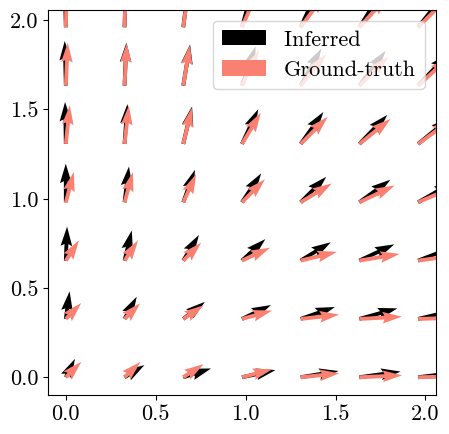

In [66]:
def drift_analytical(x,model_params_):

    a1,a2,b1,b2,K1,K2,n = model_params_
    
    force = np.zeros_like(x);
    x1n = x[:,0]**n; x2n = x[:,1]**n
    force[:,0] = (a1*x1n/((K1**n) + x1n)) + (b1*(K1**n)/((K1**n) + x2n));
    force[:,1] = (a2*x2n/((K2**n) + x2n)) + (b2*(K2**n)/((K2**n) + x1n));
    return force
    
growth_net.eval()
drift_net.eval()

Ngrid = 50; viz_time = 0.5
x_ = np.linspace(0,2,Ngrid); y_ = np.linspace(0,2,Ngrid);
xx_, yy_ = np.meshgrid(x_,y_);

xtest = np.vstack([xx_.flatten(), yy_.flatten(), viz_time*np.ones((Ngrid**2,))]).T
force  = drift_analytical(xtest[:,0:Ndim],model_params) 
xtest = torch.tensor(xtest , dtype=torch.float32, device=device)

if(TrajNet):
    drift  = drift_net(xtest).cpu().data.numpy()
else:
    drift = drift_net(xtest[:,0:Ndim]).cpu().data.numpy()

print(" RMSE ", np.mean(( (force - drift)**2 ).flatten())/np.mean( (force**2).flatten() )  )

res = 8;
plt.quiver(xx_[::res,::res],yy_[::res,::res],drift[::,0].reshape(Ngrid,Ngrid)[::res,::res],drift[::,1].reshape(Ngrid,Ngrid)[::res,::res],width=0.01,scale=25,label='Inferred ')
plt.quiver(xx_[::res,::res],yy_[::res,::res],force[::,0].reshape(Ngrid,Ngrid)[::res,::res],force[::,1].reshape(Ngrid,Ngrid)[::res,::res],color='salmon',width=0.01,scale=25,label='Ground-truth')
plt.legend(loc='best')
plt.gcf().set_size_inches(5,5)

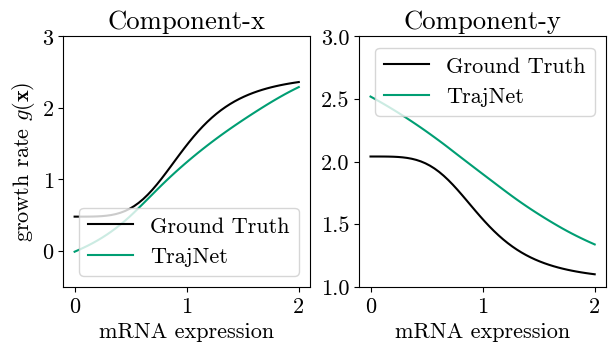

In [61]:
plt.subplot(1,2,1)
plt.plot(y_, force[:,0].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='black',label='Ground Truth')
plt.plot(y_, drift[:,0].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='#009E73',label='TrajNet')
plt.xlabel('mRNA expression'); plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.title('Component-x')
plt.ylim(-0.5,3)
plt.gcf().set_size_inches(7,3)

plt.subplot(1,2,2)
plt.plot(y_, force[:,1].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='black',label='Ground Truth')
plt.plot(y_, drift[:,1].reshape(Ngrid,Ngrid)[int(Ngrid/2),:],color='#009E73',label='TrajNet')
plt.xlabel('mRNA expression'); #plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.title('Component-y')
plt.ylim(1,3)
plt.gcf().set_size_inches(7,3.25)

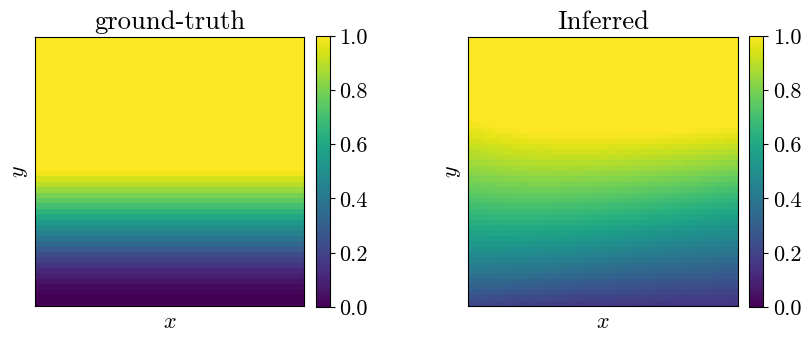

In [62]:
xtest = np.vstack([xx_.flatten(), yy_.flatten()]).T
growth_ = gr*( 1.0*(xtest[:,1]**2)/(1+xtest[:,1]**2)  + 0.0*(xtest[:,0]**2)/(1+xtest[:,0]**2) )

plt.subplot(1,2,1)
plt.imshow(growth_.reshape(Ngrid,Ngrid),origin='lower',vmin=0,vmax=1)
plt.title('ground-truth')
plt.xticks([]); plt.yticks([]);
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.colorbar(pad=0.04, fraction=0.046)

plt.subplot(1,2,2)
xtest_torch = torch.tensor(xtest,dtype=torch.float32).to(device)
growth_inf = growth_net(xtest_torch).squeeze(-1).cpu().data.numpy()
plt.imshow(growth_inf.reshape(Ngrid,Ngrid),origin='lower',vmin=0,vmax=1)
plt.title('Inferred')
plt.xticks([]); plt.yticks([]);
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.colorbar(pad=0.04, fraction=0.046)

plt.tight_layout()
plt.gcf().set_size_inches(9,4)

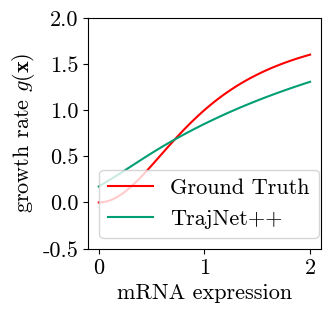

In [63]:
plt.plot(y_, growth_.reshape(Ngrid,Ngrid)[:,int(Ngrid/2)],color='red',label='Ground Truth')
plt.plot(y_, growth_inf.reshape(Ngrid,Ngrid)[:,int(Ngrid/2)],color='#009E73',label='TrajNet++')
plt.xlabel('mRNA expression'); plt.ylabel(r'growth rate $g(\mathbf{x})$')
plt.legend(loc='best')
plt.ylim(-0.5,2)
plt.gcf().set_size_inches(3,3)